# 1. Initialization and data generation

In [74]:
import numpy as np
import time
from sklearn.neighbors import KNeighborsClassifier
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import time

# --- Test parameters --- 
N_SAMPLES = 50000 # N - 100, 1000 , 10000 , 50000
N_FEATURES = 30     
N_NEIGHBORS = 5     # K 3 , 5 , 7 
TEST_SIZE = 0.2    
N_CLASSES = 2
SEED = 42

# Set the PyTorch device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device used: {DEVICE.type.upper()}\n")

# --- Data generation ---
X, y = make_classification(n_samples=N_SAMPLES, n_features=N_FEATURES, 
                           n_informative=20, n_redundant=10, 
                           n_classes=N_CLASSES , random_state=SEED)

# Test and train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)

print(f"Training dimensions: X={X_train.shape}, y={y_train.shape}")
print(f"Testing dimensions: X={X_test.shape}\n")

PyTorch device used: CUDA

Training dimensions: X=(40000, 30), y=(40000,)
Testing dimensions: X=(10000, 30)



In [75]:
import pandas as pd

try:
    df
except NameError:
    df = pd.DataFrame(columns=[ "Algorithm", 'Device',
    "Samples",
    "Features",
    "Neighbours",
    "Time(s)",
   "Accuracy",
                               
])
df

,Algorithm,Device,Samples,Features,Neighbours,Time(s),Accuracy


# 1. MANUAL IMPLEMENTATION (NUMPY)

In [76]:

algorithm= 'MANUAL IMPLEMENTATION (NUMPY)'
def knn_numpy(X_train, X_test, y_train, k):
    """
    Calculates the Euclidean distance and returns the predictions
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    
    #  d^2 = a^2 - 2ab + b2 
    a2 = np.sum(X_test**2, axis=1, keepdims=True)
    b2 = np.sum(X_train**2, axis=1, keepdims=False)
    ab = X_test.dot(X_train.T)
    distances_sq = a2 - 2 * ab + b2
    indices = np.argsort(distances_sq, axis=1)[:, :k]
    # Results in a (num_test, k) matrix with the labels of the neighbors
    nearest_labels = y_train[indices]
    # We need to find the most frequent class in each row (axis=1)
    num_classes = np.max(y_train) + 1
    
    # Apply np.bincount on each row to count the votes
    # and np.argmax to find the class with the most votes
    predictions = np.apply_along_axis(
        lambda row: np.argmax(np.bincount(row, minlength=num_classes)), 
        axis=1, 
        arr=nearest_labels
    )
    
    return predictions

In [77]:
import matplotlib.pyplot as plt

print(f"--- Running algorithm: {algorithm} ---")

start_time_manual = time.perf_counter()
predictions_manual = knn_numpy(X_train, X_test, y_train, N_NEIGHBORS)
end_time_manual = time.perf_counter()
time_manual = end_time_manual - start_time_manual

print("--- 1. Manual NumPy (Vectorized CPU) ---")

print(f"Prediction time: {time_manual:.4f} seconds\n")
accuracy = accuracy_score(y_test, predictions_manual)
print(f"\nAccuracy: {accuracy * 100:.2f}%")
cm = confusion_matrix(y_test, predictions_manual)

print("\nConfusion Matrix (text format):")
print(cm)

--- Running algorithm: MANUAL IMPLEMENTATION (NUMPY) ---
--- 1. Manual NumPy (Vectorized CPU) ---
Prediction time: 16.6559 seconds


Accuracy: 95.98%

Confusion Matrix (text format):
[[4786  171]
 [ 231 4812]]


In [78]:
new_row  = {    "Algorithm": algorithm,
            "Device" : DEVICE.type.upper(),
    "Samples": N_SAMPLES,
    "Features": N_FEATURES,
    "Neighbours": N_NEIGHBORS,
    "Time(s)": time_manual, 
      "Accuracy":accuracy,     }

df.loc[len(df)] = new_row

In [79]:
df

,Algorithm,Device,Samples,Features,Neighbours,Time(s),Accuracy
0,MANUAL IMPLEMENTATION (NUMPY),CUDA,50000,30,5,16.655881,0.9598


# 2. SCIKIT-LEARN IMPLEMENTATION

In [80]:
algorithm= 'SCIKIT-LEARN IMPLEMENTATION'
def knn_sklearn(X_train, X_test, y_train, k):
    """
    Standard Scikit-learn implementation using optimized trees
    """
    model = KNeighborsClassifier(n_neighbors=k, algorithm='auto', n_jobs=-1) 
    model.fit(X_train, y_train) 
    
    return model.predict(X_test)




In [81]:
import matplotlib.pyplot as plt

print(f"--- Running algorithm: {algorithm} ---")

start_time = time.perf_counter()

predictions_sklearn = knn_sklearn(X_train, X_test, y_train, N_NEIGHBORS)

end_time = time.perf_counter()
time_sklearn = end_time - start_time

print(f"Prediction time: {time_sklearn:.4f} seconds")
print(f"Predictions (first 10): {predictions_sklearn[:10]}")

accuracy_sk = accuracy_score(y_test, predictions_sklearn)
print(f"\nScikit-learn accuracy: {accuracy_sk * 100:.2f}%")

cm_sk = confusion_matrix(y_test, predictions_sklearn)

print("\nConfusion Matrix (text format):")
print(cm_sk)


--- Running algorithm: SCIKIT-LEARN IMPLEMENTATION ---
Prediction time: 1.5298 seconds
Predictions (first 10): [0 0 1 0 0 1 1 1 1 1]

Scikit-learn accuracy: 95.98%

Confusion Matrix (text format):
[[4786  171]
 [ 231 4812]]


In [82]:
new_row  = {    "Algorithm": algorithm,
            "Device" : DEVICE.type.upper(),
    "Samples": N_SAMPLES,
    "Features": N_FEATURES,
    "Neighbours": N_NEIGHBORS,
    "Time(s)": time_sklearn, 
   "Accuracy":accuracy_sk, }

df.loc[len(df)] = new_row

In [83]:
df

,Algorithm,Device,Samples,Features,Neighbours,Time(s),Accuracy
0,MANUAL IMPLEMENTATION (NUMPY),CUDA,50000,30,5,16.655881,0.9598
1,SCIKIT-LEARN IMPLEMENTATION,CUDA,50000,30,5,1.529783,0.9598


# 3. PYTORCH IMPLEMENTATION

In [84]:
try:
    algorithm = 'PYTORCH IMPLEMENTATION'
    
    def knn_pytorch(X_train, X_test, y_train, k):
        """
        Calculates distances on the GPU (PyTorch), votes, and returns the predictions.
        """
        # Convert to tensors and move to device (GPU)
        X_train_t = torch.from_numpy(X_train).float().to(DEVICE)
        X_test_t = torch.from_numpy(X_test).float().to(DEVICE)
        y_train_t = torch.from_numpy(y_train).long().to(DEVICE)

        X_test_sq = torch.sum(X_test_t**2, dim=1, keepdim=True)
        X_train_sq = torch.sum(X_train_t**2, dim=1, keepdim=True).T
        ab = X_test_t @ X_train_t.T
        distances_sq = X_test_sq - 2 * ab + X_train_sq
        
        # 2. Finding the K nearest distances on the GPU
        distances, indices = torch.topk(distances_sq, k, largest=False)
        
        # 3. Extract the labels of the neighbors (now y_train_t is defined)
        nearest_labels = y_train_t[indices]

        predictions = torch.mode(nearest_labels, dim=1).values
        
        # GPU-CPU synchronization
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
            
        return predictions.cpu().numpy()
        
except Exception:
    # If CUDA/cuML is not available, just print the message
    print("cannot run the code")

In [85]:
try:
    print(f"--- Running algorithm: {algorithm} ---")

    start_time_pytorch = time.perf_counter()
    
    predictions_pytorch = knn_pytorch(X_train, X_test, y_train, N_NEIGHBORS)
    
    end_time_pytorch = time.perf_counter()
    time_pytorch = end_time_pytorch - start_time_pytorch
    print(f"--- 3. PyTorch {DEVICE.type.upper()} ---")
    print(f"Prediction time: {time_pytorch:.4f} seconds\n")
    print(f"Predictions (first 10): {predictions_pytorch[:10]}")
    accuracy_pt = accuracy_score(y_test, predictions_pytorch)
    print(f"\nPyTorch accuracy: {accuracy_pt * 100:.2f}%")
    cm_torch = confusion_matrix(y_test, predictions_pytorch)
    
    print("\nConfusion Matrix (text format):")
    print(cm_torch)
except Exception:
    # If CUDA/cuML is not available, just print the message
    print("cannot run the code")


--- Running algorithm: PYTORCH IMPLEMENTATION ---
--- 3. PyTorch CUDA ---
Prediction time: 0.0555 seconds

Predictions (first 10): [0 0 1 0 0 1 1 1 1 1]

PyTorch accuracy: 95.98%

Confusion Matrix (text format):
[[4786  171]
 [ 231 4812]]


In [86]:
try:
    new_row  = {    "Algorithm": algorithm,
                "Device" : DEVICE.type.upper(),
        "Samples": N_SAMPLES,
        "Features": N_FEATURES,
        "Neighbours": N_NEIGHBORS,
        "Time(s)": time_pytorch, 
         "Accuracy": accuracy_pt     }
    
    df.loc[len(df)] = new_row

except Exception:
  
    print("cannot run the code")


In [87]:
df

,Algorithm,Device,Samples,Features,Neighbours,Time(s),Accuracy
0,MANUAL IMPLEMENTATION (NUMPY),CUDA,50000,30,5,16.655881,0.9598
1,SCIKIT-LEARN IMPLEMENTATION,CUDA,50000,30,5,1.529783,0.9598
2,PYTORCH IMPLEMENTATION,CUDA,50000,30,5,0.055519,0.9598


# 4. JAX IMPLEMENTATION

In [88]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial


# JAX
DEVICE_JAX = jax.default_backend()
print(f"JAX device used: {DEVICE_JAX.upper()}\n")

algorithm = 'JAX IMPLEMENTATION'

@jit
def squared_euclidean_distance(a, b):
    return jnp.sum(jnp.square(a - b))

@partial(jit, static_argnums=(3, 4))
def _predict_single(x_test_point, X_train_data, y_train_data, k, num_classes):
    
    # 1. Calculate distances
    distances = vmap(squared_euclidean_distance, in_axes=(None, 0))(x_test_point, X_train_data)

    nearest_indices = jnp.argsort(distances)[:k]

    nearest_labels = y_train_data[nearest_indices]

    # Use length=num_classes for JIT compatibility
    predicted_class = jnp.argmax(jnp.bincount(nearest_labels, length=num_classes))
    
    return predicted_class

# Main JAX function 
def knn_jax_predict(X_train, X_test, y_train, k, num_classes):
    
    # 1. Transfer data to device (including y_train)
    X_train_jax = jax.device_put(X_train)
    X_test_jax = jax.device_put(X_test)
    y_train_jax = jax.device_put(y_train) # NEW
    # Static arguments (k, num_classes) are at indices 3 and 4
    batch_predict_fn = jit(
        vmap(
            _predict_single, 
            in_axes=(0, None, None, None, None) # Map X_test, broadcast the rest
        ),
        static_argnums=(3, 4) 
    )
    
    #  Warm-up run (compiles JIT)
    _ = batch_predict_fn(X_test_jax[:1], X_train_jax, y_train_jax, k, num_classes).block_until_ready()
    
    # 4. Actual prediction run
    print(f"Running JAX prediction on {X_test_jax.shape[0]} samples...")
    predictions_jax = batch_predict_fn(X_test_jax, X_train_jax, y_train_jax, k, num_classes)
    predictions_jax.block_until_ready()

    return np.array(predictions_jax)

JAX device used: GPU



In [89]:
print(f"--- Running algorithm: {algorithm} ---")

#  Measure time and get predictions
start_time_jax = time.perf_counter()


predictions_jax = knn_jax_predict(X_train, X_test, y_train, N_NEIGHBORS, N_CLASSES)

end_time_jax = time.perf_counter()
time_jax = end_time_jax - start_time_jax
print(f"--- 4. JAX {DEVICE_JAX.upper()} ---")
print(f"Prediction time: {time_jax:.4f} seconds\n")
print(f"Predictions (first 10): {predictions_jax[:10]}")

#  Compute accuracy 
accuracy_jax = accuracy_score(y_test, predictions_jax)
print(f"\nJAX Accuracy: {accuracy_jax * 100:.2f}%")

#  Compute and display the confusion matrix 
cm_jax = confusion_matrix(y_test, predictions_sklearn)

print("\nConfusion Matrix (text format):")
print(cm_jax)


--- Running algorithm: JAX IMPLEMENTATION ---
Running JAX prediction on 10000 samples...
--- 4. JAX GPU ---
Prediction time: 2.8596 seconds

Predictions (first 10): [0 0 1 0 0 1 1 1 1 1]

JAX Accuracy: 95.98%

Confusion Matrix (text format):
[[4786  171]
 [ 231 4812]]


In [90]:
new_row  = {    "Algorithm": algorithm,
            "Device" : DEVICE.type.upper(),
    "Samples": N_SAMPLES,
    "Features": N_FEATURES,
    "Neighbours": N_NEIGHBORS,
    "Time(s)": time_jax, 
           "Accuracy": accuracy_jax  }

df.loc[len(df)] = new_row

# 5. FAISS IMPLEMENTATION

In [91]:
pip install faiss-cpu

/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [92]:
try:
    import faiss
    algorithm = 'FAISS IMPLEMENTATION'
    
    def knn_faiss(X_train, X_test, y_train, k, num_classes):
        """
        Runs FAISS, finds neighbors, performs voting, and returns predictions.
        """
        print("\n--- Running FAISS KNN (with Prediction) ---")
        
        #  FAISS requires float32 data
        X_train_faiss = X_train.astype(np.float32)
        X_test_faiss = X_test.astype(np.float32)
        
        d = X_train_faiss.shape[1] # Vector dimension
    
        #  Creating a "brute-force" L2 index
        index = faiss.IndexFlatL2(d)
        
        #  Adding training data to the index
    
        index.add(X_train_faiss)
       
      
    
        #  Searching for neighbors 
    
        # D = distances, I = indices
        D, I = index.search(X_test_faiss, k)

        
        #  Voting 
    
        
        # 'I' has shape (N_test, k)
        nearest_labels = y_train[I]

        predictions = np.apply_along_axis(
            lambda row: np.argmax(np.bincount(row, minlength=num_classes)), 
            axis=1, 
            arr=nearest_labels
        )
        
    
        
        # Return the final predictions
        return predictions
except Exception:
    # If FAISS is not available, just print the message
    print("cannot run the code")

In [93]:
try:
    print(f"--- Running algorithm: {algorithm} ---")
    
    # --- 1. Measure the time and obtain predictions ---
    start_time_faiss = time.perf_counter()
    
    # Call the MODIFIED function with 5 arguments
    predictions_faiss = knn_faiss(X_train, X_test, y_train, N_NEIGHBORS, N_CLASSES)
    
    end_time_faiss = time.perf_counter()
    time_faiss = end_time_faiss - start_time_faiss
    print(f"Prediction time: {time_faiss:.4f} seconds\n")
    print(f"Predictions (first 10): {predictions_faiss[:10]}")
    
    
    # --- 2. Compute accuracy ---
    accuracy_faiss = accuracy_score(y_test, predictions_faiss)
    print(f"\nFAISS Accuracy: {accuracy_faiss * 100:.2f}%")
    
    # --- 3. Compute and display the confusion matrix ---
    cm_faiss = confusion_matrix(y_test, predictions_faiss)
    
    print("\nConfusion Matrix (text format):")
    print(cm_faiss)

except Exception:
    # If CUDA/cuML is not available, just display the message
    print("cannot run the code")
   

--- Running algorithm: FAISS IMPLEMENTATION ---

--- Running FAISS KNN (with Prediction) ---
Prediction time: 0.4045 seconds

Predictions (first 10): [0 0 1 0 0 1 1 1 1 1]

FAISS Accuracy: 95.98%

Confusion Matrix (text format):
[[4786  171]
 [ 231 4812]]


In [94]:
try:
    new_row  = {    "Algorithm": algorithm,
                "Device" : DEVICE.type.upper(),
        "Samples": N_SAMPLES,
        "Features": N_FEATURES,
        "Neighbours": N_NEIGHBORS,
        "Time(s)": time_faiss,
               "Accuracy":accuracy_faiss}
    
    df.loc[len(df)] = new_row
except Exception:
    
    print("nu se poate rula codul")  

# 6. RAPIDS cuML IMPLEMENTATION (only T4 GPU)

In [95]:
 if DEVICE.type == 'cuda':
    !pip install cuml-cu12 cupy-cuda12x cudf-cu12
else:
    print('CUDA is not available')


/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [96]:
algorithm = 'RAPIDS IMPLEMENTATION'
try:
    import cupy as cp
    from cuml.neighbors import KNeighborsClassifier as cuKNeighbors
    algoritm = 'RAPIDS cuML IMPLEMENTATION (GPU)'
    
    def knn_rapids_predict(X_train_cpu, X_test_cpu, y_train_cpu, k):
        """
        Runs cuML KNeighborsClassifier on GPU.
        Does .fit(), .predict() and returns the predictions on CPU.
        """
        
        # Transfer data CPU -> GPU 
        X_train_gpu = cp.array(X_train_cpu.astype(np.float32))
        X_test_gpu = cp.array(X_test_cpu.astype(np.float32))
        y_train_gpu = cp.array(y_train_cpu.astype(np.int32))
        
        # Synchronize
        cp.cuda.Stream.null.synchronize() 
        
        # We use Classifier, not NearestNeighbors
        knn_gpu =  cuKNeighbors(n_neighbors=k, algorithm='brute')
        
        knn_gpu.fit(X_train_gpu, y_train_gpu)
        
        cp.cuda.Stream.null.synchronize() 
    
        # Make the prediction 
        predictions_gpu = knn_gpu.predict(X_test_gpu)
        
        cp.cuda.Stream.null.synchronize() 
    
        # Bring the predictions back to CPU
        predictions_cpu = cp.asnumpy(predictions_gpu)
        
        # Return predictions (NumPy array)
        return predictions_cpu
        
except Exception:
  
    print("T4 GPU is not enabled - cannot run the code")

T4 GPU is not enabled - cannot run the code


In [97]:
try:
    print(f"--- Running algorithm: {algorithm} ---")
    
    # --- 1. Measure the time and obtain predictions ---
    start_time_rapids = time.perf_counter()
    
    # Call the MODIFIED function with 4 arguments
    predictions_rapids = knn_rapids_predict(X_train, X_test, y_train, N_NEIGHBORS)
    
    end_time_rapids = time.perf_counter()
    time_rapids = end_time_rapids - start_time_rapids
    print(f"Response time (search): {time_rapids:.4f} seconds\n")
    print(f"Prediction time: {time_rapids:.4f} seconds\n")
    print(f"Predictions (first 10): {predictions_rapids[:10]}")
    
    
    # --- 2. Compute accuracy ---
    accuracy_rapids = accuracy_score(y_test, predictions_rapids)
    print(f"\nRAPIDS cuML Accuracy: {accuracy_rapids * 100:.2f}%")
    
    # --- 3. Compute and display the confusion matrix ---
    cm_rapids = confusion_matrix(y_test, predictions_rapids)
    
    print("\nConfusion Matrix (text format):")
    print(cm_rapids)
    
except Exception:
  
    print("The T4 GPU is not enabled – the code cannot be executed")


--- Running algorithm: RAPIDS IMPLEMENTATION ---
The T4 GPU is not enabled – the code cannot be executed


In [98]:
try:
    new_row  = {    "Algorithm": algorithm,
                "Device" : DEVICE.type.upper(),
        "Samples": N_SAMPLES,
        "Features": N_FEATURES,
        "Neighbours": N_NEIGHBORS,
        "Time(s)": time_rapids,
               "Accuracy":accuracy_rapids}
    
    df.loc[len(df)] = new_row
except Exception:
  
    print("The T4 GPU is not enabled – the code cannot be executed")

The T4 GPU is not enabled – the code cannot be executed


In [99]:
print(df)

                       Algorithm Device  Samples  Features  Neighbours  \
0  MANUAL IMPLEMENTATION (NUMPY)   CUDA    50000        30           5   
1    SCIKIT-LEARN IMPLEMENTATION   CUDA    50000        30           5   
2         PYTORCH IMPLEMENTATION   CUDA    50000        30           5   
3             JAX IMPLEMENTATION   CUDA    50000        30           5   
4           FAISS IMPLEMENTATION   CUDA    50000        30           5   

     Time(s)  Accuracy  
0  16.655881    0.9598  
1   1.529783    0.9598  
2   0.055519    0.9598  
3   2.859580    0.9598  
4   0.404549    0.9598  


# VISUALIZATION


In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

try:
    time_rapids
except NameError:
    print("Time_rapids is not defined.")
    time_rapids = 0
else:
    print("Time_rapids is defined")
    

algorithms = ["NUMPY", "SCIKIT-LEARN", 'PYTORCH', 'JAX', 'FAISS', 'RAPIDS']
times = [time_manual, time_sklearn, time_pytorch, time_jax, time_faiss, time_rapids]

data_barplot = pd.DataFrame({
    'Algorithms': algorithms,
    'Time(seconds)': times
})

data_barplot

Time_rapids is defined


,Algorithms,Time(seconds)
0,NUMPY,16.655881
1,SCIKIT-LEARN,1.529783
2,PYTORCH,0.055519
3,JAX,2.859580
4,FAISS,0.404549
5,RAPIDS,0.000000


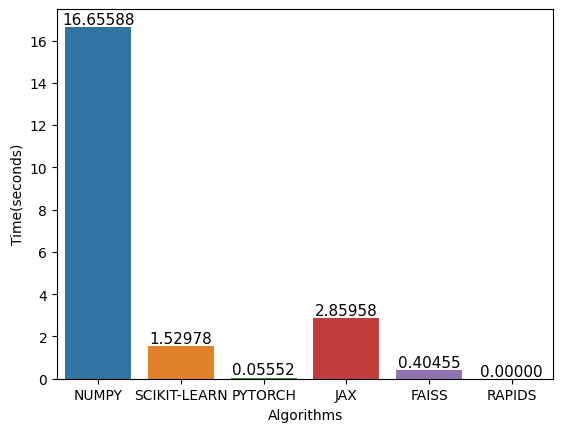

In [101]:
fig, ax = plt.subplots()
sns.barplot(data=data_barplot, x='Algorithms', y='Time(seconds)' , ax=ax)
for p in ax.patches: 
    ax.annotate(f'{p.get_height():.5f}',        
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='bottom', fontsize=11, color='black')

# LOG

In [102]:

import pandas as pd
import os

csv_filename = 'log.csv'
df.to_csv(csv_filename, mode='a', index=False, header=not os.path.exists(csv_filename))
print(f'The results have been saved in {csv_filename}')
print(df)

file = pd.read_csv('log.csv')
print(file)

The results have been saved in log.csv
                       Algorithm Device  Samples  Features  Neighbours  \
0  MANUAL IMPLEMENTATION (NUMPY)   CUDA    50000        30           5   
1    SCIKIT-LEARN IMPLEMENTATION   CUDA    50000        30           5   
2         PYTORCH IMPLEMENTATION   CUDA    50000        30           5   
3             JAX IMPLEMENTATION   CUDA    50000        30           5   
4           FAISS IMPLEMENTATION   CUDA    50000        30           5   

     Time(s)  Accuracy  
0  16.655881    0.9598  
1   1.529783    0.9598  
2   0.055519    0.9598  
3   2.859580    0.9598  
4   0.404549    0.9598  
                        Algorithm Device  Samples  Features  Neighbours  \
0   MANUAL IMPLEMENTATION (NUMPY)   CUDA    50000        30           5   
1     SCIKIT-LEARN IMPLEMENTATION   CUDA    50000        30           5   
2              JAX IMPLEMENTATION   CUDA    50000        30           5   
3            FAISS IMPLEMENTATION   CUDA    50000        30       

In [103]:
del df
